# Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("gold.csv")
df.head()


,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,IsWeekend,IsMonthStart,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,Target_Next_Close,Close_Lag1,Open_Lag1,Daily_Return
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,0,0,0.5,0.866025,0.433884,-0.900969,110.86,NaN,NaN,0.004663
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,0,0,0.5,0.866025,-0.433884,-0.900969,NaN,112.03,111.51,-0.004401
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0.5,0.866025,0.000000,1.000000,111.52,110.86,111.35,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,0,0,0.5,0.866025,0.781831,0.623490,108.94,NaN,NaN,0.005137
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,0,0,0.5,0.866025,0.974928,-0.222521,107.37,111.52,110.95,-0.009366


## Check Data Quality

### Out of Order Dates Verification

In [4]:
df = pd.read_csv("gold.csv")
df["date"] = pd.to_datetime(df["date"])

print("Date range:", df["date"].min(), "to", df["date"].max())
print("Duplicate dates:", df["date"].duplicated().sum())
print("Dates out of order:", not df["date"].is_monotonic_increasing)

Date range: 2010-01-14 00:00:00 to 2024-10-23 00:00:00
Duplicate dates: 0
Dates out of order: False


### Missing Values Check

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
print(missing[missing > 0])

GDP                   3847
CPI                   3728
us_rates_%            3728
usd_chf                210
eur_usd                210
Target_Next_Close      186
Close_Lag1             186
Open_Lag1              186
platinum open          185
sp500 open             185
platinum low           185
platinum volume        185
platinum high-low      185
palladium open         185
palladium high         185
palladium low          185
platinum close         185
platinum high          185
oil volume             185
palladium close        185
palladium volume       185
palladium high-low     185
gold open              185
gold high              185
gold low               185
gold close             185
gold volume            185
oil high-low           185
Daily_Return           185
oil close              185
nasdaq volume          185
sp500 high             185
sp500 low              185
sp500 close            185
oil low                185
sp500 high-low         185
nasdaq open            185
n

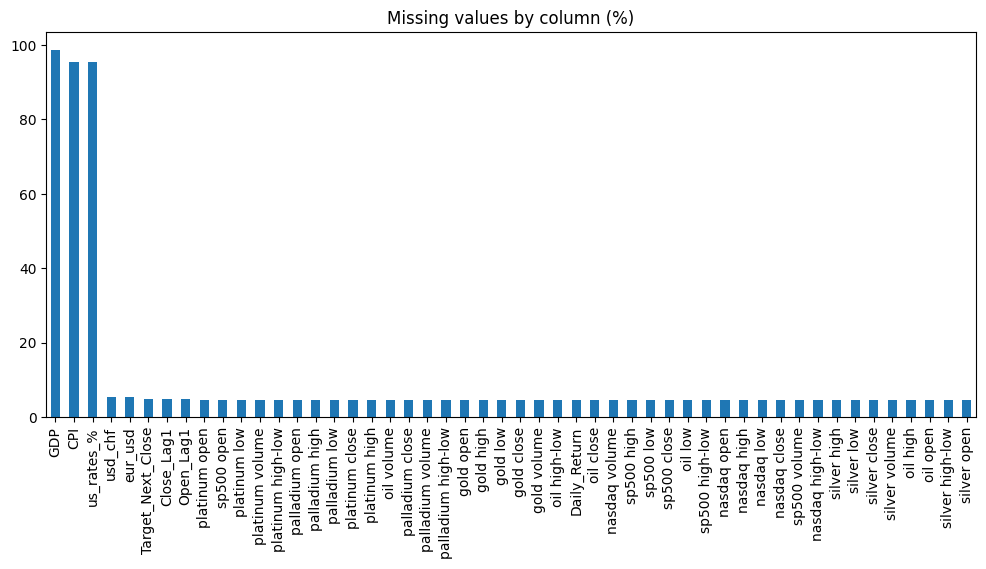

In [6]:
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0].plot(
    kind="bar", figsize=(12, 5), title="Missing values by column (%)"
);

### Rows with Missing Prices

In [7]:
market_cols = [
    col for col in df.columns
    if any(name in col for name in ["gold", "silver", "oil", "platinum",
                                    "palladium", "sp500", "nasdaq"])
]

empty_market = df[market_cols].isna().all(axis=1)

print("Rows with all market values missing:", empty_market.sum())
print(df.loc[empty_market, "date"].head(10))

Rows with all market values missing: 185
2     2010-01-18
22    2010-02-15
56    2010-04-02
77    2010-05-01
98    2010-05-31
123   2010-07-05
143   2010-08-01
169   2010-09-06
227   2010-11-25
248   2010-12-24
Name: date, dtype: datetime64[ns]


### First Three and Last Three Dates of us_rates, CPI, GDP

In [9]:
macro_cols = ["us_rates_%", "CPI", "GDP"]

for col in macro_cols:
    print(f"\n{col}:")
    print(df.loc[df[col].notna(), ["date", col]].head(3))
    print(df.loc[df[col].notna(), ["date", col]].tail(3))


us_rates_%:
         date  us_rates_%
12 2010-02-01        0.13
32 2010-03-01        0.16
55 2010-04-01        0.20
           date  us_rates_%
3820 2024-07-01        5.33
3843 2024-08-01        5.33
3865 2024-09-01        5.13

CPI:
         date      CPI
12 2010-02-01  217.281
32 2010-03-01  217.353
55 2010-04-01  217.403
           date      CPI
3820 2024-07-01  313.534
3843 2024-08-01  314.121
3865 2024-09-01  314.686

GDP:
          date        GDP
55  2010-04-01  14980.193
121 2010-07-01  15141.607
188 2010-10-01  15309.474
           date        GDP
3623 2023-10-01  28296.967
3689 2024-01-01  28624.069
3754 2024-04-01  29016.714


## Plot Gold Over Time

### Plot of Gold Overtime

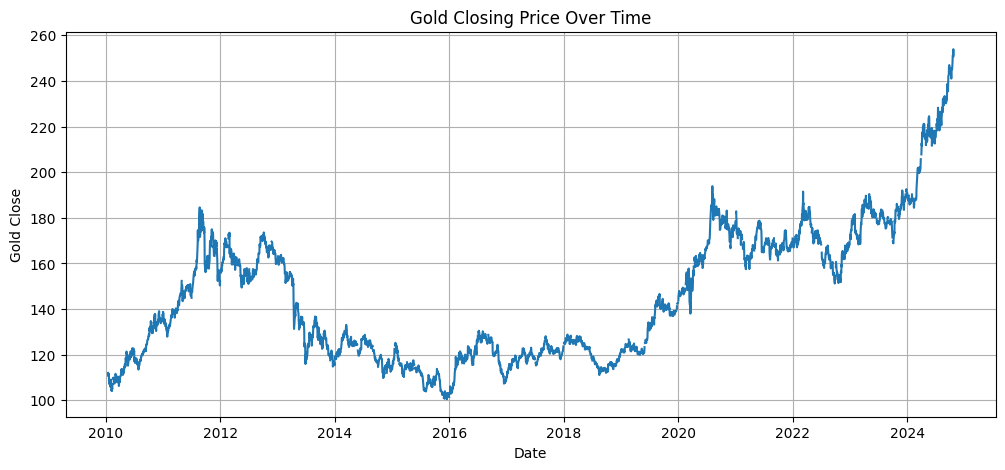

In [10]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["gold close"])
plt.title("Gold Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Close")
plt.grid(True)
plt.show()

### Plot of Gold Daily Returns

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_20487/3206632717.py:1: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["daily_return_pct"] = df["gold close"].pct_change() * 100


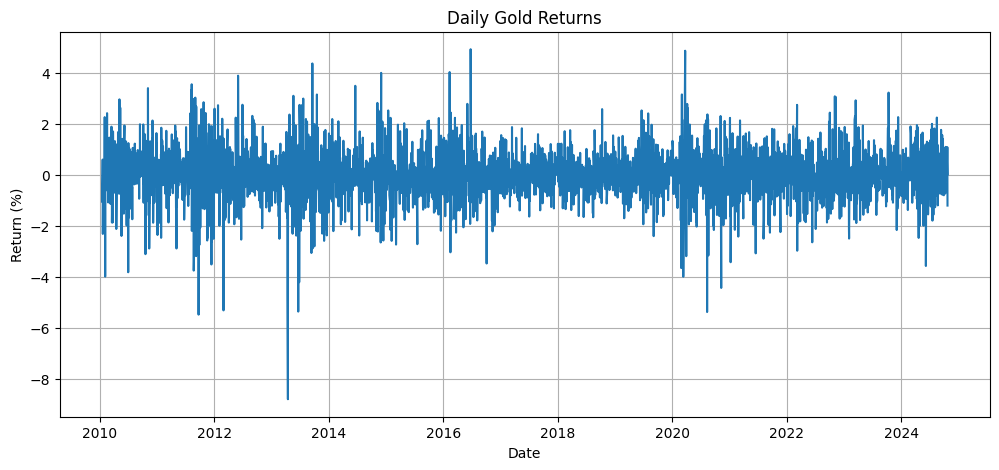

In [13]:
df["daily_return_pct"] = df["gold close"].pct_change() * 100

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["daily_return_pct"])
plt.title("Daily Gold Returns")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

### Rolling Volatility plot

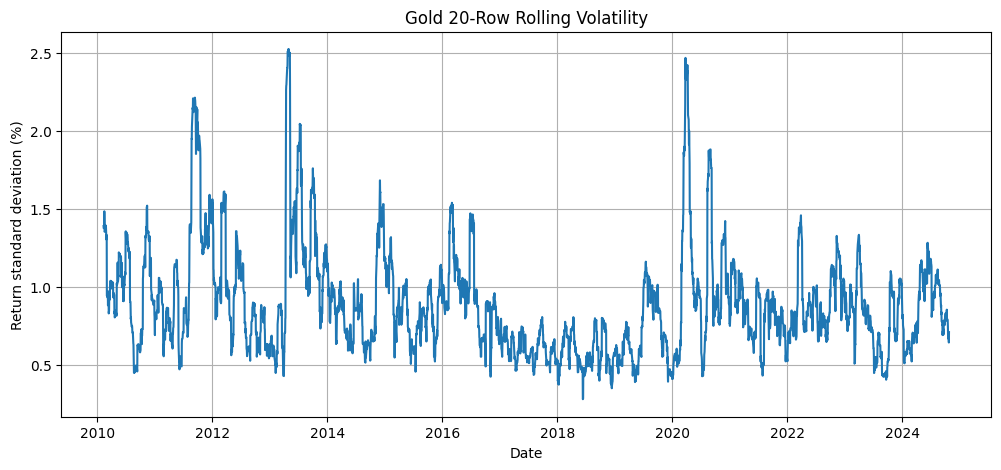

In [14]:
df["rolling_volatility"] = df["daily_return_pct"].rolling(20).std()

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["rolling_volatility"])
plt.title("Gold 20-Row Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Return standard deviation (%)")
plt.grid(True)
plt.show()

## Check Daily Price Behavior

### Daily Price Behavior

In [16]:
price_cols = ["gold open", "gold high", "gold low", "gold close"]

# Keep rows that have all four gold prices
gold_prices = df[price_cols].dropna()

print("Rows where high < low:",
      (gold_prices["gold high"] < gold_prices["gold low"]).sum())

print("Rows where close is outside the day's range:",
      ((gold_prices["gold close"] > gold_prices["gold high"]) |
       (gold_prices["gold close"] < gold_prices["gold low"])).sum())

Rows where high < low: 0
Rows where close is outside the day's range: 0


### Daily Gold Price High, Low, and Close

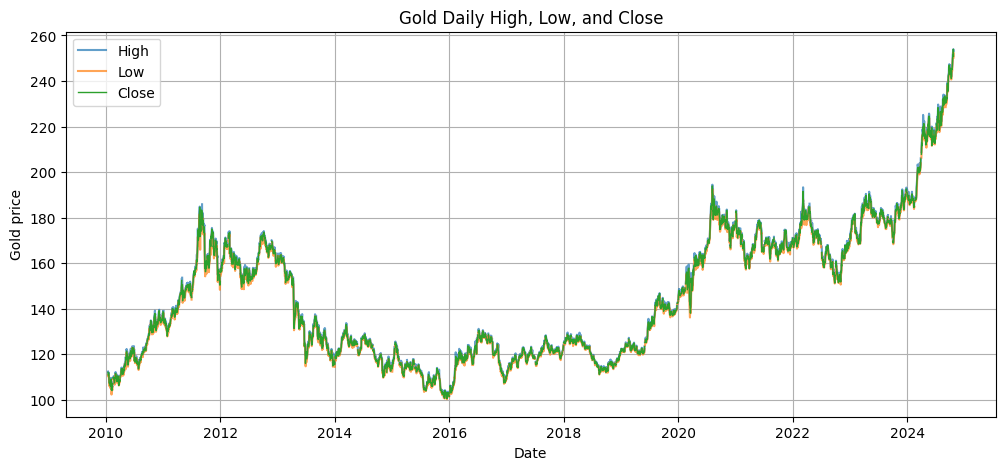

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["gold high"], label="High", alpha=0.7)
plt.plot(df["date"], df["gold low"], label="Low", alpha=0.7)
plt.plot(df["date"], df["gold close"], label="Close", linewidth=1)
plt.title("Gold Daily High, Low, and Close")
plt.xlabel("Date")
plt.ylabel("Gold price")
plt.legend()
plt.grid(True)
plt.show()

### Large Daily Gold Price Changes

In [22]:
# Calculate percentage change from the previous available gold close
df = df.sort_values("date").copy()
df["gold_return"] = df["gold close"].pct_change()

# Show the 10 largest moves in either direction
largest_moves = (
    df.loc[df["gold_return"].abs().nlargest(10).index,
           ["date", "gold open", "gold high", "gold low",
            "gold close", "gold_return"]]
    .sort_values("gold_return")
)

largest_moves

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_20487/1783781117.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["gold_return"] = df["gold close"].pct_change()


,date,gold open,gold high,gold low,gold close,gold_return
857,2013-04-15,136.0000,136.7500,130.510,131.310,-0.087808
445,2011-09-23,164.5100,165.7200,158.550,159.800,-0.054718
2795,2020-08-11,183.5700,183.9800,179.430,179.940,-0.053694
906,2013-06-20,125.2178,126.3800,123.330,123.600,-0.053526
560,2012-02-29,173.1900,173.5900,164.000,164.286,-0.053052
856,2013-04-12,148.6500,148.8499,143.426,143.950,-0.047004
2860,2020-11-09,176.4200,176.4500,173.640,175.080,-0.044271
2693,2020-03-23,142.6750,146.9300,142.280,146.300,0.044180
2694,2020-03-24,153.5000,155.6600,152.050,153.400,0.048530
1703,2016-06-24,126.6200,126.8200,125.000,126.010,0.049122


### Distribution of Daily Gold Returns

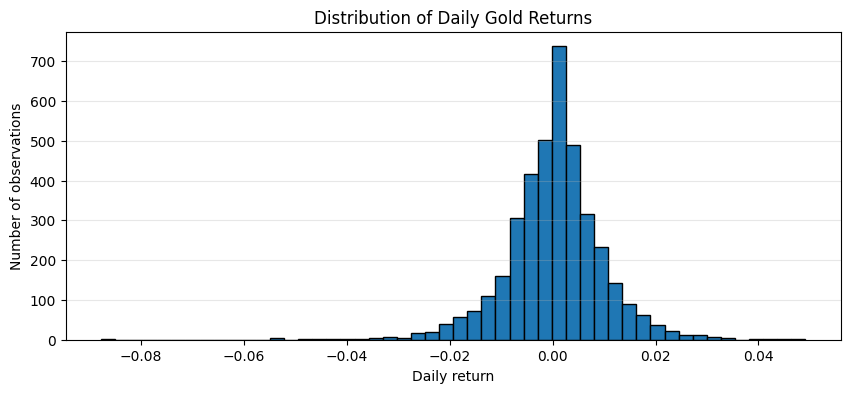

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.hist(df["gold_return"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Daily Gold Returns")
plt.xlabel("Daily return")
plt.ylabel("Number of observations")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Examine Relationships Between Market Returns

In [19]:
market_closes = [
    "gold close",
    "silver close",
    "oil close",
    "platinum close",
    "palladium close",
    "sp500 close",
    "nasdaq close",
]

returns = df[market_closes].pct_change()

/var/folders/8z/9f9b14l53y99c8m3pl4l8krc0000gn/T/ipykernel_20487/381165926.py:11: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df[market_closes].pct_change()


### Corr Between Daily Market Returns

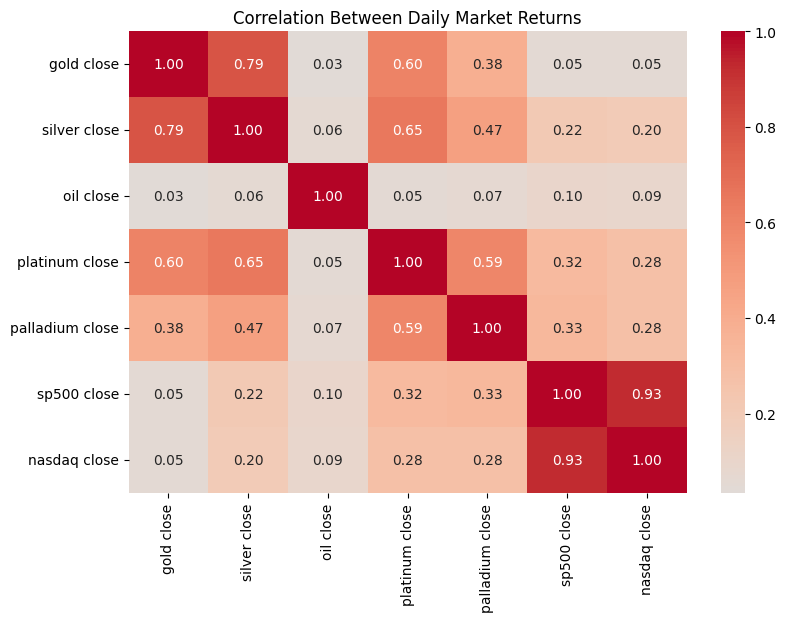

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))
sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Between Daily Market Returns")
plt.show()

### Gold Corr with its Returns

In [21]:
gold_corr = returns.corr()["gold close"].drop("gold close")
print(gold_corr.sort_values())

oil close          0.032840
sp500 close        0.051400
nasdaq close       0.052743
palladium close    0.384452
platinum close     0.603410
silver close       0.789561
Name: gold close, dtype: float64


## Review Macroeconomic and Calendar Features

### Check Macro Reporting Frequency

In [24]:
macro_cols = ["us_rates_%", "CPI", "GDP"]

for col in macro_cols:
    available = df.loc[df[col].notna(), ["date", col]].sort_values("date")
    print(f"\n{col}: {len(available)} recorded values")
    print("First and last recorded dates:")
    display(pd.concat([available.head(3), available.tail(3)]))


us_rates_%: 176 recorded values
First and last recorded dates:


,date,us_rates_%
12,2010-02-01,0.13
32,2010-03-01,0.16
55,2010-04-01,0.20
3820,2024-07-01,5.33
3843,2024-08-01,5.33
3865,2024-09-01,5.13



CPI: 176 recorded values
First and last recorded dates:


,date,CPI
12,2010-02-01,217.281
32,2010-03-01,217.353
55,2010-04-01,217.403
3820,2024-07-01,313.534
3843,2024-08-01,314.121
3865,2024-09-01,314.686



GDP: 57 recorded values
First and last recorded dates:


,date,GDP
55,2010-04-01,14980.193
121,2010-07-01,15141.607
188,2010-10-01,15309.474
3623,2023-10-01,28296.967
3689,2024-01-01,28624.069
3754,2024-04-01,29016.714


### Check Calendar Features Against Date

In [26]:
dates = pd.to_datetime(df["date"])

checks = {
    "Year matches date": df["Year"].eq(dates.dt.year),
    "Month matches date": df["Month"].eq(dates.dt.month),
    "DayOfWeek matches date (Monday=0)": df["DayOfWeek"].eq(dates.dt.dayofweek),
    "Quarter matches date": df["Quarter"].eq(dates.dt.quarter),
    "IsWeekend matches date": df["IsWeekend"].eq(dates.dt.dayofweek >= 5),
}

for label, result in checks.items():
    print(f"{label}: {result.sum()} of {len(df)} rows match")

Year matches date: 3904 of 3904 rows match
Month matches date: 3904 of 3904 rows match
DayOfWeek matches date (Monday=0): 3904 of 3904 rows match
Quarter matches date: 3904 of 3904 rows match
IsWeekend matches date: 3904 of 3904 rows match


## Check the Prediction Target

### Check Target_Next_Close Matches gold close

In [28]:
df = df.sort_values("date").reset_index(drop=True)

# Compare the target with the next row's gold close
expected_target = df["gold close"].shift(-1)
matches = df["Target_Next_Close"].eq(expected_target) | (
    df["Target_Next_Close"].isna() & expected_target.isna()
)

print("Target matches next row:", matches.sum(), "of", len(df))

Target matches next row: 3904 of 3904


### Check Target Distribution and Skewness

count    3718.000000
mean      145.462851
std        29.610255
min       100.500000
25%       120.595000
50%       137.725000
75%       167.837500
max       253.930000
Name: Target_Next_Close, dtype: float64
Target skewness: 0.7745834075696926


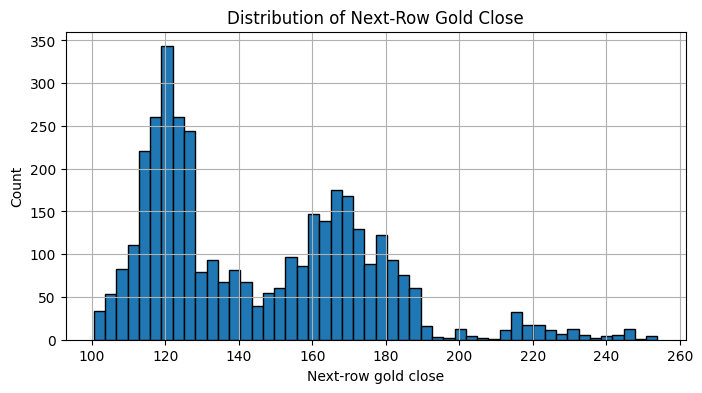

In [29]:
target = df["Target_Next_Close"].dropna()

print(target.describe())
print("Target skewness:", target.skew())

target.hist(bins=50, figsize=(8, 4), edgecolor="black")
plt.title("Distribution of Next-Row Gold Close")
plt.xlabel("Next-row gold close")
plt.ylabel("Count")
plt.show()

### Next Row Percentage Change

count    3543.000000
mean        0.000234
std         0.009703
min        -0.087808
25%        -0.004772
50%         0.000409
75%         0.005278
max         0.049122
dtype: float64
Next-row return skewness: -0.417654351425224


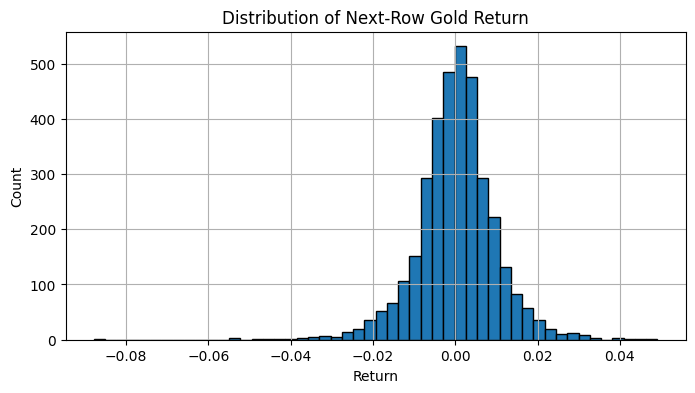

In [30]:
next_return = df["Target_Next_Close"] / df["gold close"] - 1

print(next_return.describe())
print("Next-row return skewness:", next_return.skew())

next_return.dropna().hist(bins=50, figsize=(8, 4), edgecolor="black")
plt.title("Distribution of Next-Row Gold Return")
plt.xlabel("Return")
plt.ylabel("Count")
plt.show()